In [1]:
# ============================================================
# BLOCK 1: Import Libraries
# ============================================================
# We import all libraries upfront so that all later cells work smoothly.
# - numpy, pandas: numerical and tabular operations
# - matplotlib, seaborn: plotting and visualization
# - tensorflow/keras: deep learning framework (recommended in the assignment)
# - sklearn: evaluation metrics (precision, recall, F1, confusion matrix)
# - os, zipfile, random: file handling and reproducibility
# ============================================================

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras for building CNN models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D, Input)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn for evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Set random seeds so results are reproducible (important for viva — examiner can re-run)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check if GPU is available — training is much faster on GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# BLOCK 0a: Helpers to survive Colab disconnects
# ============================================================
# Two helpers are set up here:
#   1. A directory where we save trained models and history dicts
#      so a runtime disconnect does not lose hours of training.
#   2. A keep-alive script that periodically clicks the connect
#      button so an idle session stays connected.
# ============================================================

import os
import pickle

SAVE_DIR = "/content/saved"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory ready:", SAVE_DIR)

def save_history(history_obj, name):
    """Save the .history dict from a Keras History object."""
    path = os.path.join(SAVE_DIR, f"{name}_history.pkl")
    with open(path, "wb") as f:
        pickle.dump(history_obj.history, f)
    print(f"Saved history to {path}")

def save_model(model, name):
    """Save a Keras model in the native .keras format."""
    path = os.path.join(SAVE_DIR, f"{name}.keras")
    model.save(path)
    print(f"Saved model to {path}")

# Keep-alive: this runs in the browser, not Python. It clicks the
# Colab "connect" button every minute so an idle session does not
# get reclaimed.
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    console.log("Keep-alive ping");
    var btn = document.querySelector("colab-toolbar-button#connect");
    if (btn) btn.click();
}
setInterval(ClickConnect, 60000);
'''))
print("Keep-alive script started.")

Save directory ready: /content/saved


<IPython.core.display.Javascript object>

Keep-alive script started.


In [3]:
# ============================================================
# BLOCK 2: Extract the dataset
# ============================================================
# The Intel Image Classification dataset has 6 classes:
# buildings, forest, glacier, mountain, sea, street.
# It is already pre-split into train, val, and test folders.
# We extract the zip into Colab's working directory so Keras
# can read images directly from the folder structure.
# ============================================================

import os
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted, skipping.")

# Define paths to train, val, test folders
BASE_DIR  = "/content/dataset/Intel-Image-Classification"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Verify folders and list classes
print("\nTrain folder:", os.listdir(TRAIN_DIR))
print("Val folder:  ", os.listdir(VAL_DIR))
print("Test folder: ", os.listdir(TEST_DIR))

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nFound {NUM_CLASSES} classes: {CLASS_NAMES}")

Extraction complete.

Train folder: ['sea', 'mountain', 'glacier', 'forest', 'buildings', 'street']
Val folder:   ['sea', 'mountain', 'glacier', 'forest', 'buildings', 'street']
Test folder:  ['sea', 'mountain', 'glacier', 'forest', 'buildings', 'street']

Found 6 classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Class           Train      Val     Test
----------------------------------------
buildings        1972      219      437
forest           2044      227      474
glacier          2164      240      553
mountain         2261      251      525
sea              2047      227      510
street           2144      238      501
----------------------------------------
TOTAL           12632     1402     3000

Grand total: 17034 images


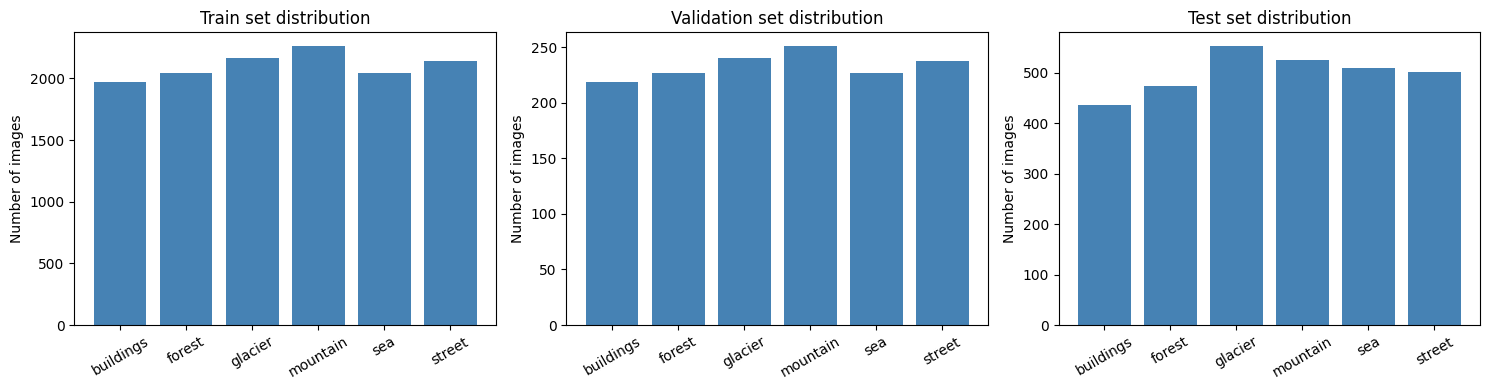

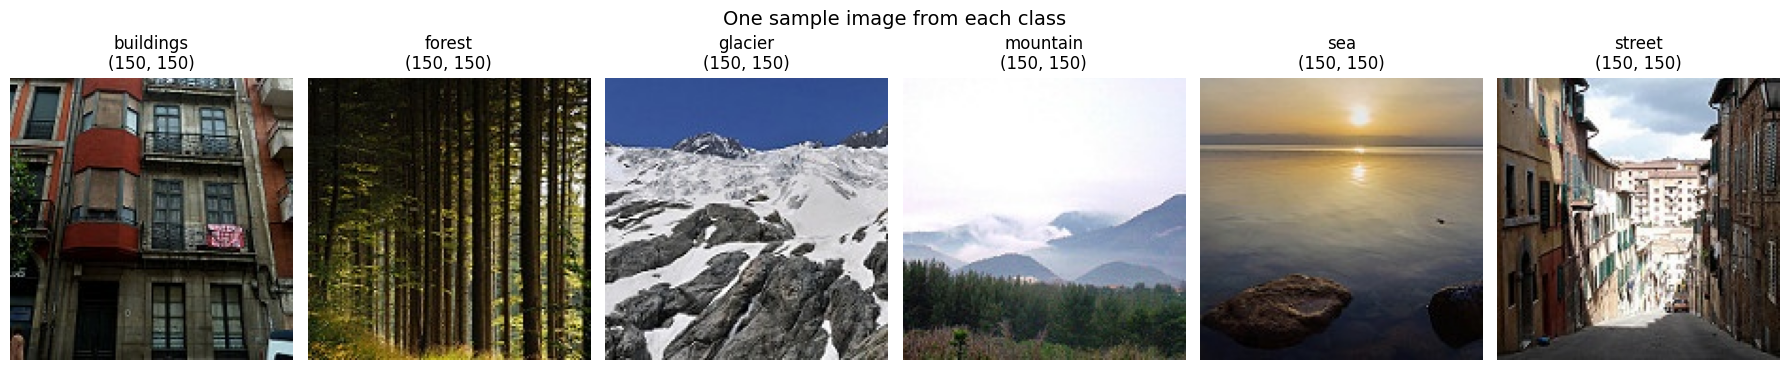


Unique image sizes found in a sample of training images:
{(150, 140), (150, 136), (150, 150)}

If there are multiple sizes, we will resize all images to a fixed size.


In [4]:
# ============================================================
# BLOCK 3: Data Understanding and Visualization
# ============================================================
# The assignment requires us to describe the dataset before modeling:
#   - What it represents
#   - Total image count
#   - Distribution per class (balanced or imbalanced)
#   - Train / val / test split sizes
#   - Sample visualizations
#
# We do not load all images into memory. We just count files in each
# folder and read a few samples for plotting. This is fast and avoids
# memory issues on Colab.
# ============================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

# ---------- Step 1: Count images in each split and class ----------

def count_images(folder):
    """
    Walks through a split folder (train / val / test) and counts
    how many images each class has. Returns a dictionary
    {class_name: count}.
    """
    counts = {}
    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Print the counts as a small table
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for cls in CLASS_NAMES:
    print(f"{cls:<12} {train_counts[cls]:>8} {val_counts[cls]:>8} {test_counts[cls]:>8}")

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
print("-" * 40)
print(f"{'TOTAL':<12} {total_train:>8} {total_val:>8} {total_test:>8}")
print(f"\nGrand total: {total_train + total_val + total_test} images")


# ---------- Step 2: Plot class distribution ----------

# A bar chart shows whether classes are balanced. If one class has
# many more images than another, the model can become biased toward it.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, counts) in zip(axes, [("Train", train_counts),
                                      ("Validation", val_counts),
                                      ("Test", test_counts)]):
    ax.bar(counts.keys(), counts.values(), color="steelblue")
    ax.set_title(f"{title} set distribution")
    ax.set_ylabel("Number of images")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


# ---------- Step 3: Show one sample image from each class ----------

# Looking at sample images helps confirm the labels are correct
# and gives an idea of what the model has to learn.

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_folder = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(cls_folder)[0]   # take the first image
    img = Image.open(os.path.join(cls_folder, sample_file))
    ax.imshow(img)
    ax.set_title(f"{cls}\n{img.size}")        # also show resolution
    ax.axis("off")

plt.suptitle("One sample image from each class", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- Step 4: Check image sizes ----------

# CNN models expect a fixed input size. We check whether all images
# already have the same dimensions, or if we need to resize them.

sizes_seen = set()
for cls in CLASS_NAMES:
    cls_folder = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_folder)[:20]:   # sample 20 per class
        img = Image.open(os.path.join(cls_folder, fname))
        sizes_seen.add(img.size)

print("\nUnique image sizes found in a sample of training images:")
print(sizes_seen)
print("\nIf there are multiple sizes, we will resize all images to a fixed size.")

In [5]:
# ============================================================
# BLOCK 4: Data Generators and Augmentation
# ============================================================
# Loading all images into memory is not feasible. ImageDataGenerator
# loads images in batches from disk, applies preprocessing, and
# optionally augments training images on the fly.
#
# Key choices made here:
#   - Image size: 150 x 150. The Intel dataset images are around
#     150 x 150 already, so resizing to this size avoids quality loss
#     and keeps training fast.
#   - Batch size: 32. A common default that balances speed and
#     gradient stability on a T4 GPU.
#   - Rescale 1/255: pixel values originally range 0-255. Dividing
#     by 255 brings them to 0-1, which helps the network train
#     more stably (gradients stay in a reasonable range).
#   - Augmentation (training only): horizontal flip, small rotation,
#     zoom, and shift. These create slightly different versions of
#     each training image every epoch, which reduces overfitting
#     because the model never sees the exact same image twice.
#   - No augmentation on validation and test sets, so evaluation
#     stays consistent and reproducible.
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions and batch size used throughout the project
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# ---------- Training generator with augmentation ----------
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,          # normalize pixel values to [0, 1]
    rotation_range=15,          # rotate images up to 15 degrees
    width_shift_range=0.1,      # shift horizontally up to 10%
    height_shift_range=0.1,     # shift vertically up to 10%
    zoom_range=0.1,             # zoom in or out up to 10%
    horizontal_flip=True,       # randomly flip left-right
    fill_mode="nearest"         # fill empty pixels after a shift
)

# ---------- Validation and test generators (no augmentation) ----------
# We only rescale here. Augmentation on validation or test data would
# make evaluation noisy and would not represent real-world performance.
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ---------- flow_from_directory ----------
# This reads images directly from class-named subfolders, automatically
# assigns labels based on folder names, and yields batches.
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # one-hot labels for multi-class
    shuffle=True,               # shuffle each epoch for better training
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False               # keep order for reproducible validation
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False               # important: no shuffle so predictions
                                # align with true labels for the report
)

# Confirm class index mapping (Keras assigns indices alphabetically)
print("\nClass index mapping:", train_generator.class_indices)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Class index mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


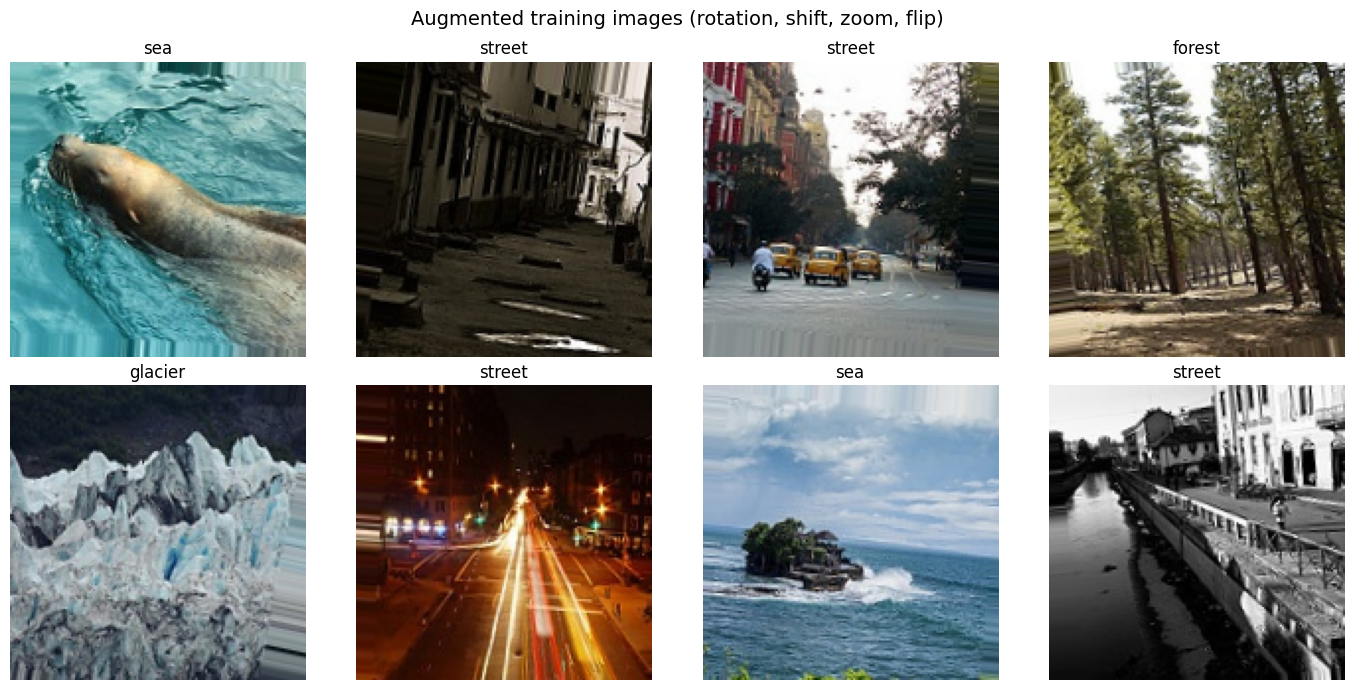

In [6]:
# ============================================================
# BLOCK 5: Visualize Augmented Images
# ============================================================
# We pull one batch from the training generator and display a few
# augmented examples. This proves augmentation is working and
# gives us images to include in the report.
# ============================================================

import matplotlib.pyplot as plt

# Take one batch (32 images) from the training generator
images, labels = next(train_generator)

# Reverse the class index mapping so we can show class names
index_to_class = {v: k for k, v in train_generator.class_indices.items()}

# Plot 8 augmented images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    label_idx = labels[i].argmax()             # one-hot to class index
    ax.set_title(index_to_class[label_idx])
    ax.axis("off")

plt.suptitle("Augmented training images (rotation, shift, zoom, flip)",
             fontsize=14)
plt.tight_layout()
plt.show()

# Reset the generator so training starts from the first batch.
# This matters because we already consumed one batch above.
train_generator.reset()

In [7]:
# ============================================================
# BLOCK 6: Baseline CNN Model
# ============================================================
# The assignment requires a baseline CNN with this structure:
#   - 3 convolutional layers, each followed by a pooling layer
#   - 3 fully connected (dense) layers
#   - 1 output layer for classification
#
# Design choices explained:
#   - Conv2D filters increase with depth (32, 64, 128). Early layers
#     learn low-level features (edges, colors) and need fewer filters.
#     Deeper layers learn complex patterns and need more filters.
#   - Kernel size (3, 3): the standard small kernel. Small kernels
#     stacked in multiple layers can capture the same receptive field
#     as a large kernel but with fewer parameters.
#   - ReLU activation: introduces non-linearity and avoids vanishing
#     gradients (unlike sigmoid or tanh).
#   - MaxPooling (2, 2): halves spatial dimensions. This reduces
#     computation and gives translation invariance.
#   - Flatten before dense layers: converts 2D feature maps into
#     a 1D vector that fully connected layers can process.
#   - Softmax output: produces a probability distribution over
#     the 6 classes that sums to 1.
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    """
    Builds the baseline CNN as specified in the assignment.
    Returns an uncompiled Keras Sequential model.
    """
    model = Sequential(name="Baseline_CNN")

    # ---- Convolutional block 1 ----
    # 32 filters, kernel 3x3, then 2x2 max pool
    model.add(Conv2D(32, (3, 3), activation="relu",
                     input_shape=input_shape, padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # ---- Convolutional block 2 ----
    # 64 filters: more filters here because feature maps are smaller
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # ---- Convolutional block 3 ----
    # 128 filters: deepest conv layer captures higher-level features
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # ---- Flatten 2D feature maps into a 1D vector ----
    model.add(Flatten())

    # ---- Three fully connected layers as the assignment requires ----
    model.add(Dense(256, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(64, activation="relu"))

    # ---- Output layer ----
    # Softmax converts logits into probabilities for 6 classes
    model.add(Dense(num_classes, activation="softmax"))

    return model

# Build and inspect the model
baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

# Print the model summary so we can include it in the report
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ============================================================
# BLOCK 7: Compile and Train the Baseline Model
# ============================================================
# Compile settings:
#   - Optimizer: Adam (adaptive learning rate, fast convergence,
#     a sensible default for image classification)
#   - Loss: categorical_crossentropy (standard for multi-class
#     with one-hot labels and softmax output)
#   - Metric: accuracy (easy to interpret and report)
#
# Callbacks:
#   - EarlyStopping: stops training if validation loss does not
#     improve for several epochs. Saves time and prevents the
#     model from overfitting.
#   - ReduceLROnPlateau: lowers the learning rate when validation
#     loss plateaus, helping the model squeeze out a bit more
#     accuracy near the end of training.
#
# Epochs set to 15. With early stopping it usually finishes earlier.
# Training time on a Colab T4 GPU is roughly 1-2 minutes per epoch.
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Compile
baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for smarter training
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,                 # wait 4 epochs before stopping
    restore_best_weights=True   # keep the best weights, not the last
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,                 # halve the learning rate
    patience=2,
    min_lr=1e-6
)

# Train and time it (we will report training time in the report)
print("Starting baseline training...\n")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline training completed in {baseline_train_time/60:.2f} minutes.")

Starting baseline training...

Epoch 1/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 91s 214ms/step - accuracy: 0.5842 - loss: 1.0351 - val_accuracy: 0.6755 - val_loss: 0.8619 - learning_rate: 0.0010
Epoch 2/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 78s 197ms/step - accuracy: 0.7211 - loss: 0.7477 - val_accuracy: 0.7589 - val_loss: 0.6608 - learning_rate: 0.0010
Epoch 3/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 78s 197ms/step - accuracy: 0.7703 - loss: 0.6333 - val_accuracy: 0.7817 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 4/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 77s 195ms/step - accuracy: 0.8046 - loss: 0.5429 - val_accuracy: 0.8345 - val_loss: 0.4900 - learning_rate: 0.0010
Epoch 5/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 78s 196ms/step - accuracy: 0.8197 - loss: 0.5003 - val_accuracy: 0.8459 - val_loss: 0.4509 - learning_rate: 0.0010
Epoch 6/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 76s 192ms/step - accuracy: 0.8266 - loss: 0.4729 - val_accuracy: 0.8231 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 7/15
395/395 ━━━━━━━━━━━━━━━━━━━━

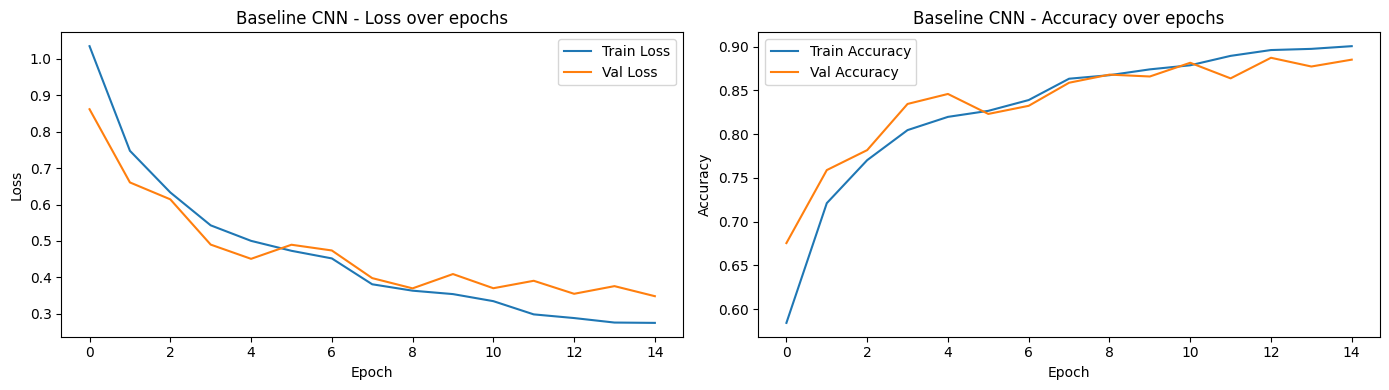


Evaluating baseline model on the test set...
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8787 - loss: 0.3558

Baseline test loss:     0.3558
Baseline test accuracy: 0.8787
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step

Classification report (Baseline):

              precision    recall  f1-score   support

   buildings       0.87      0.87      0.87       437
      forest       0.97      0.98      0.97       474
     glacier       0.88      0.77      0.83       553
    mountain       0.83      0.85      0.84       525
         sea       0.86      0.91      0.89       510
      street       0.87      0.91      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000


Summary metrics (Baseline): {'accuracy': 0.8786666666666667, 'precision': 0.8800764612820022, 'recall': 0.8812749617406866, 'f1': 0.8798398814554317, 'train_time_min': 19.461751290162404}


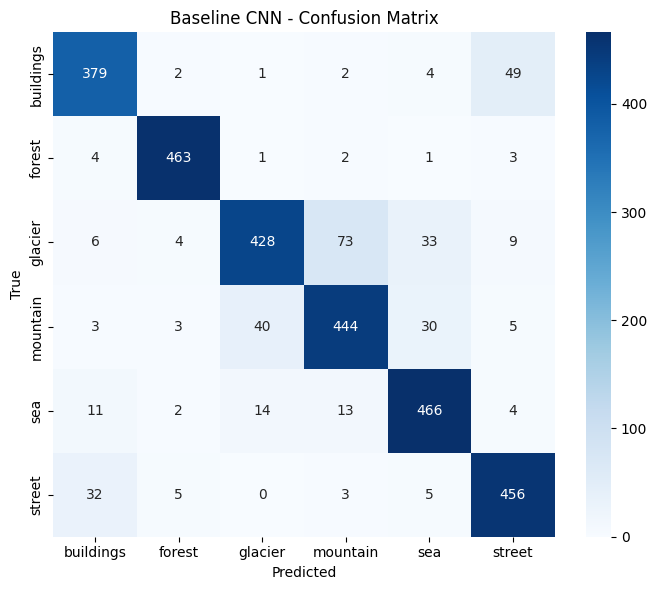

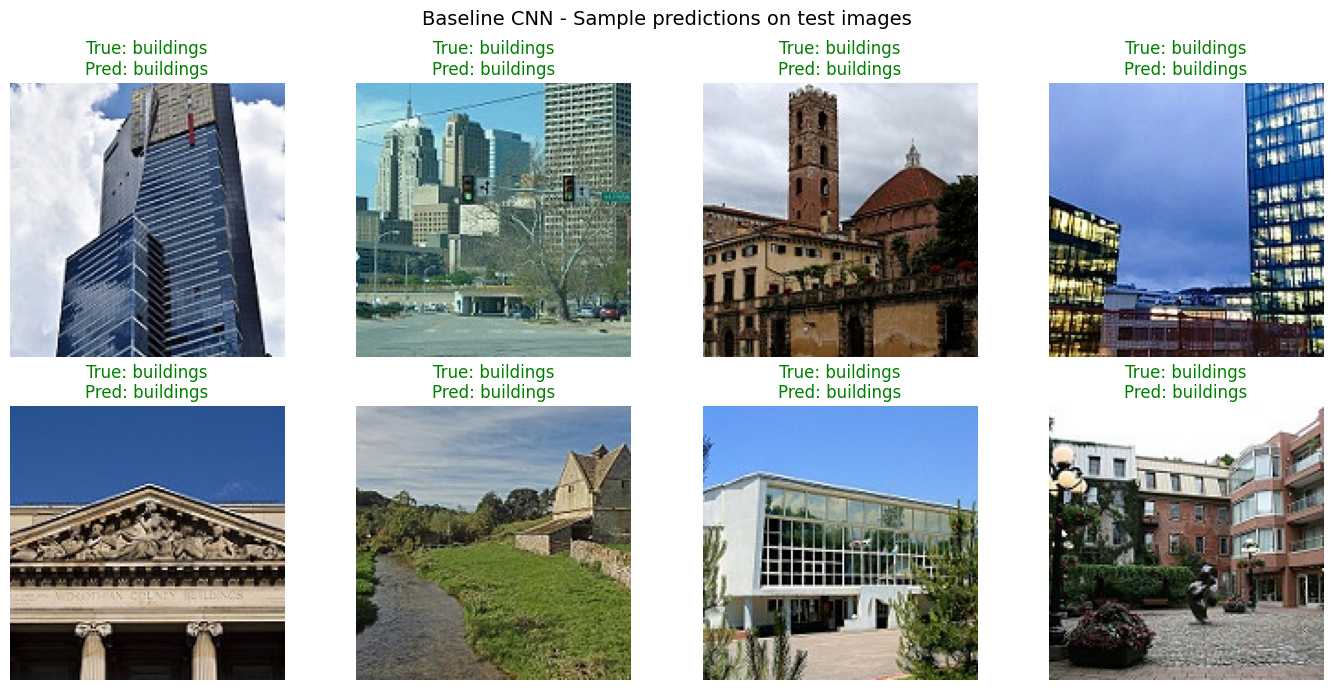

In [9]:
# ============================================================
# BLOCK 8: Evaluate the Baseline Model
# ============================================================
# Steps performed here:
#   1. Plot training vs validation loss and accuracy curves.
#      These curves reveal whether the model is overfitting,
#      underfitting, or training healthily.
#   2. Evaluate on the test set (data the model has never seen).
#      Test accuracy is the honest measure of generalization.
#   3. Compute precision, recall, and F1-score per class using
#      sklearn.classification_report.
#   4. Plot a confusion matrix to see which classes get confused
#      with each other (for example, glacier vs mountain).
#   5. Show predictions on a few sample images so we have a
#      visual qualitative check.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)


# ---------- Step 1: Plot training history ----------

def plot_history(history, title_prefix=""):
    """
    Plots loss and accuracy curves side by side.
    Reading the curves:
      - Loss should go down for both train and val.
      - If train loss keeps falling but val loss rises, the model
        is overfitting (memorizing training data).
      - If both losses stay high, the model is underfitting
        (too simple to learn the patterns).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss plot
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy plot
    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title(f"{title_prefix} Accuracy over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title_prefix="Baseline CNN -")


# ---------- Step 2: Evaluate on the test set ----------
# evaluate() returns the loss and accuracy on the test data.
# This is the headline number we report.

print("\nEvaluating baseline model on the test set...")
test_loss, test_acc = baseline_model.evaluate(test_generator, verbose=1)
print(f"\nBaseline test loss:     {test_loss:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")


# ---------- Step 3: Predictions, classification report ----------
# We get predicted probabilities for every test image, take the
# class with the highest probability (argmax), and compare against
# the true labels.

# Reset generator so predictions align with true label order.
test_generator.reset()

# Predict probabilities for all test images
y_pred_probs = baseline_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)        # predicted class index
y_true = test_generator.classes                  # true class index

# Classification report (precision, recall, F1 per class)
print("\nClassification report (Baseline):\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Headline metrics computed using macro average (treats every class equally)
baseline_metrics = {
    "accuracy":  accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, average="macro"),
    "recall":    recall_score(y_true, y_pred, average="macro"),
    "f1":        f1_score(y_true, y_pred, average="macro"),
    "train_time_min": baseline_train_time / 60
}
print("\nSummary metrics (Baseline):", baseline_metrics)


# ---------- Step 4: Confusion matrix ----------
# Rows are true classes, columns are predicted classes. The diagonal
# shows correct predictions; off-diagonal cells show confusions.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ---------- Step 5: Visual inference on sample images ----------
# Plot a few test images with their true label and predicted label.
# Green title = correct, red title = wrong. This gives a quick
# qualitative feel for where the model fails.

# Take one batch from the test generator (after reset)
test_generator.reset()
sample_imgs, sample_labels = next(test_generator)
sample_preds = baseline_model.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    true_idx = sample_labels[i].argmax()
    pred_idx = sample_preds[i].argmax()
    color = "green" if true_idx == pred_idx else "red"
    ax.set_title(
        f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}",
        color=color
    )
    ax.axis("off")

plt.suptitle("Baseline CNN - Sample predictions on test images", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# BLOCK 9: Deeper CNN with Regularization
# ============================================================
# The baseline had 3 conv blocks. The assignment asks us to at
# least double the layers and add regularization. This deeper
# network has 6 conv layers organized as 3 conv blocks, where
# each block has 2 conv layers stacked before a pooling layer.
#
# Regularization techniques used:
#   - BatchNormalization: normalizes layer activations during
#     training. This stabilizes training, allows higher learning
#     rates, and acts as a mild regularizer.
#   - Dropout: during training, randomly sets a fraction of
#     neurons to zero. This forces the network to not rely on
#     any single neuron, which reduces overfitting.
#   - Dropout rate increases with depth (0.25 in conv blocks,
#     0.5 in dense layers) because dense layers have many more
#     parameters and overfit more easily.
#
# Architecture summary:
#   Block 1: Conv(32) -> BN -> Conv(32) -> BN -> Pool -> Dropout
#   Block 2: Conv(64) -> BN -> Conv(64) -> BN -> Pool -> Dropout
#   Block 3: Conv(128) -> BN -> Conv(128) -> BN -> Pool -> Dropout
#   Flatten -> Dense(256) -> BN -> Dropout
#           -> Dense(128) -> BN -> Dropout
#           -> Dense(64)  -> BN -> Dropout
#           -> Dense(num_classes, softmax)
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      BatchNormalization, Dropout)

def build_deeper_cnn(input_shape=(150, 150, 3), num_classes=6):
    """
    Builds a deeper CNN with BatchNormalization and Dropout.
    Returns an uncompiled Keras Sequential model.
    """
    model = Sequential(name="Deeper_CNN")

    # ---- Conv block 1: two conv layers with 32 filters ----
    model.add(Conv2D(32, (3, 3), activation="relu",
                     input_shape=input_shape, padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))            # mild dropout in conv blocks

    # ---- Conv block 2: two conv layers with 64 filters ----
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # ---- Conv block 3: two conv layers with 128 filters ----
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # ---- Flatten and dense layers ----
    model.add(Flatten())

    # First dense layer with stronger dropout (0.5) since dense
    # layers have most of the parameters and overfit easily.
    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(64, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # ---- Output layer ----
    model.add(Dense(num_classes, activation="softmax"))

    return model

# Build and inspect the deeper model
deeper_model = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

# Print summary so we can compare parameter count vs baseline
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 10,949,222 (41.77 MB)

 Trainable params: 10,947,430 (41.76 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [11]:
# ============================================================
# BLOCK 10: Compile and Train the Deeper CNN
# ============================================================
# Same compile settings as baseline so the comparison is fair:
# any difference in performance comes from architecture changes,
# not from a different optimizer or loss function.
#
# We train for a few more epochs (20) because deeper models
# usually need more time to converge, but EarlyStopping will
# kick in if validation loss stops improving.
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Compile with the same settings as the baseline
deeper_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Same callbacks as baseline (fair comparison)
early_stop_d = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr_d = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Starting deeper model training...\n")
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop_d, reduce_lr_d],
    verbose=1
)

deeper_train_time = time.time() - start_time
print(f"\nDeeper model training completed in {deeper_train_time/60:.2f} minutes.")

Starting deeper model training...

Epoch 1/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 124s 263ms/step - accuracy: 0.4637 - loss: 1.4654 - val_accuracy: 0.3531 - val_loss: 1.6325 - learning_rate: 0.0010
Epoch 2/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 86s 219ms/step - accuracy: 0.6100 - loss: 1.0165 - val_accuracy: 0.6698 - val_loss: 0.8454 - learning_rate: 0.0010
Epoch 3/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 88s 222ms/step - accuracy: 0.6963 - loss: 0.8410 - val_accuracy: 0.6755 - val_loss: 0.9208 - learning_rate: 0.0010
Epoch 4/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 88s 222ms/step - accuracy: 0.7354 - loss: 0.7559 - val_accuracy: 0.5542 - val_loss: 1.1668 - learning_rate: 0.0010
Epoch 5/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 91s 230ms/step - accuracy: 0.7659 - loss: 0.6674 - val_accuracy: 0.7639 - val_loss: 0.6562 - learning_rate: 5.0000e-04
Epoch 6/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7825 - loss: 0.6367 - val_accuracy: 0.7575 - val_loss: 0.7296 - learning_rate: 5.0000e-04
Epoch 7/20
395/395 ━━━━━━━

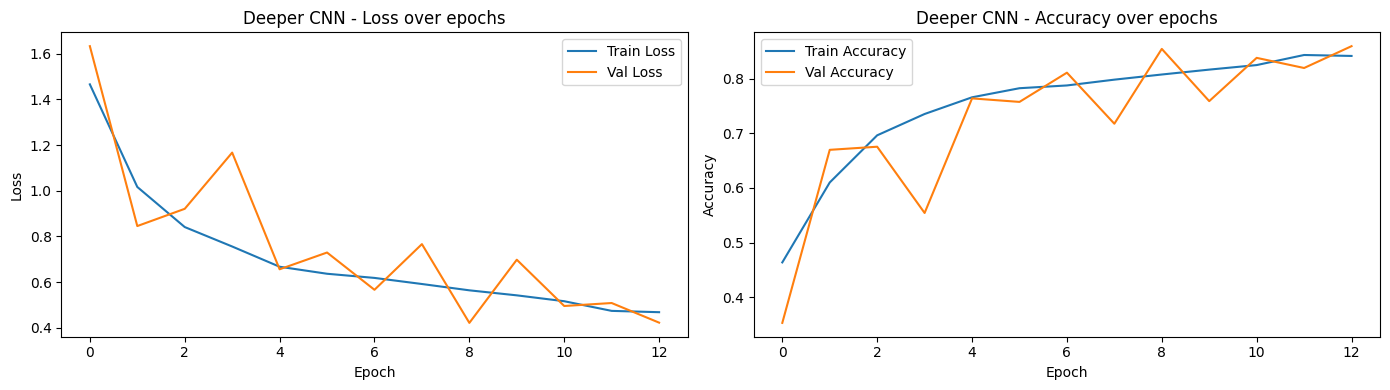


Evaluating deeper model on the test set...
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8570 - loss: 0.4168

Deeper test loss:     0.4168
Deeper test accuracy: 0.8570
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step

Classification report (Deeper):

              precision    recall  f1-score   support

   buildings       0.85      0.85      0.85       437
      forest       0.95      0.98      0.97       474
     glacier       0.81      0.85      0.83       553
    mountain       0.85      0.72      0.78       525
         sea       0.82      0.89      0.85       510
      street       0.87      0.87      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000


Summary metrics (Deeper): {'accuracy': 0.857, 'precision': 0.859033932933894, 'recall': 0.8590547523546884, 'f1': 0.8577678150398137, 'train_time_min': 20.479239861170452}


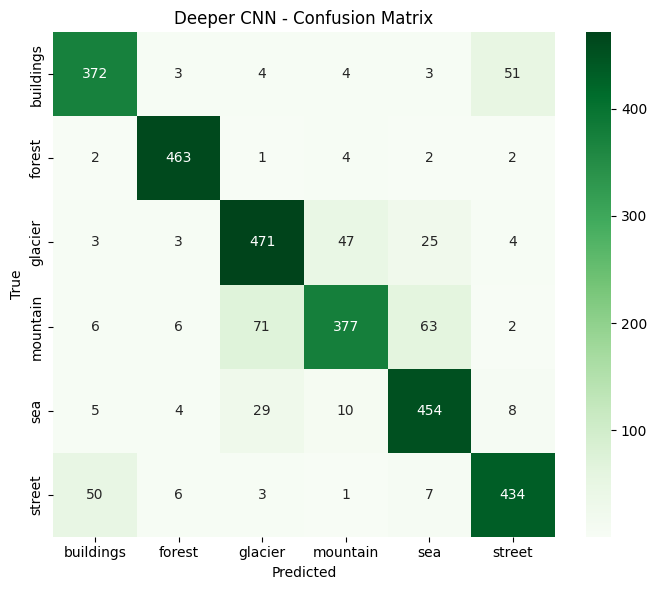

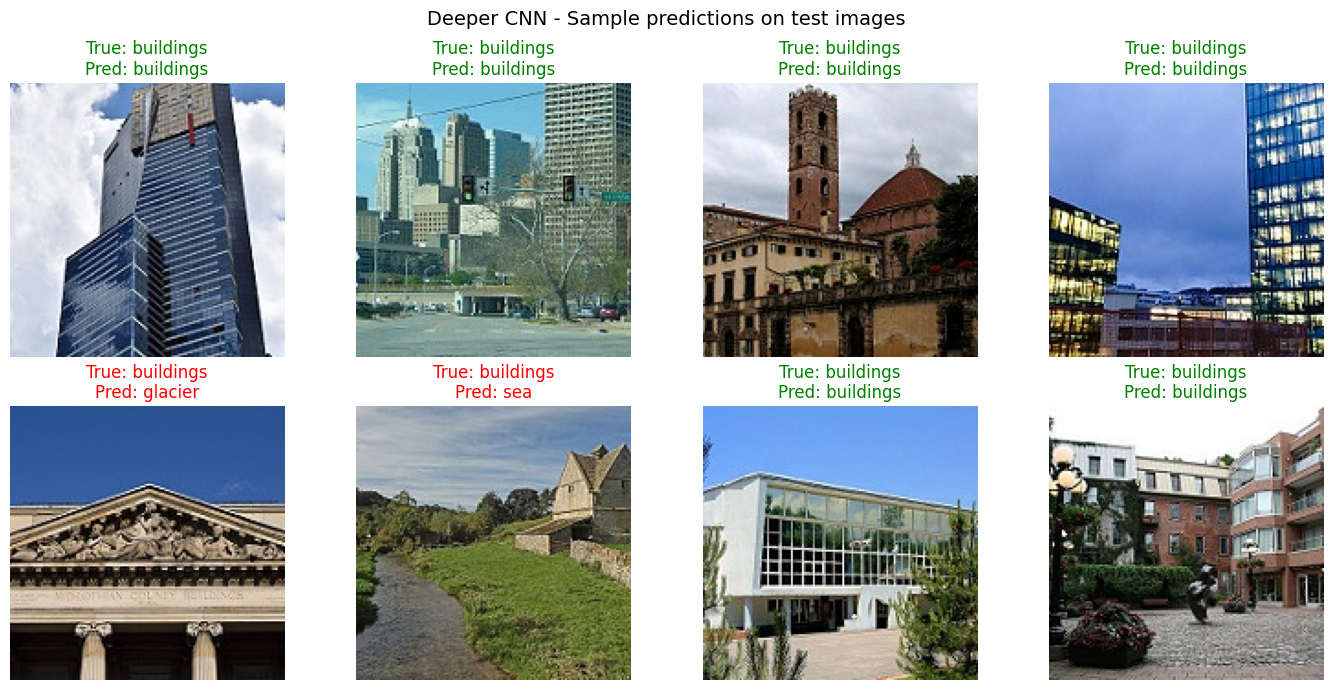


=== Comparison: Baseline vs Deeper ===
          accuracy  precision  recall      f1  train_time_min
Baseline    0.8787     0.8801  0.8813  0.8798         19.4618
Deeper      0.8570     0.8590  0.8591  0.8578         20.4792


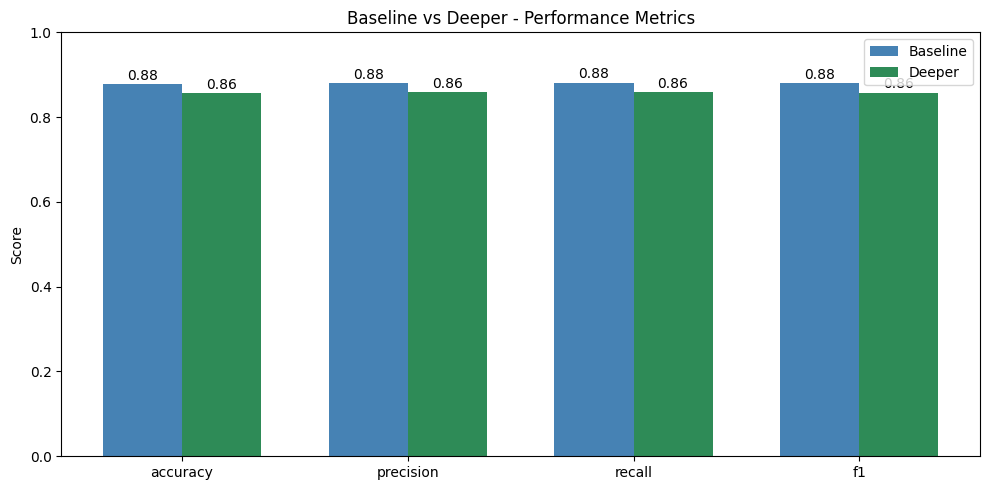

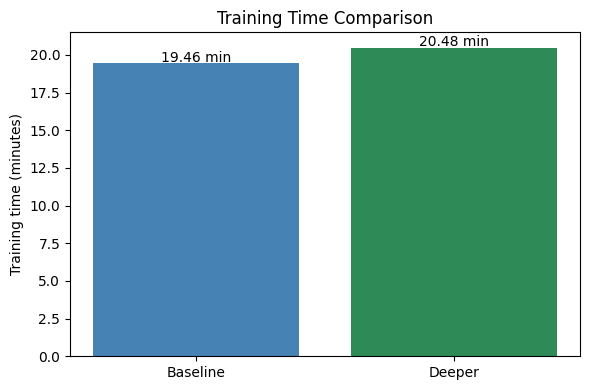

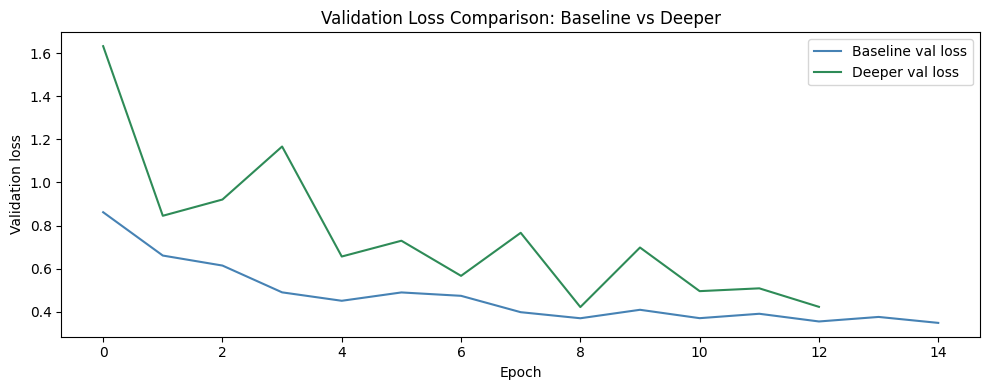

In [12]:
# ============================================================
# BLOCK 11: Evaluate Deeper Model and Compare with Baseline
# ============================================================
# We reuse the same evaluation pipeline as the baseline:
#   - Plot loss/accuracy curves
#   - Test set evaluation
#   - Classification report and confusion matrix
#   - Sample predictions
# Then we put the two models side by side in a comparison table
# and a comparison plot. This directly answers the assignment's
# question: did adding more layers and regularization help?
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)


# ---------- Step 1: Plot deeper model training curves ----------
plot_history(deeper_history, title_prefix="Deeper CNN -")


# ---------- Step 2: Evaluate on test set ----------
print("\nEvaluating deeper model on the test set...")
deeper_test_loss, deeper_test_acc = deeper_model.evaluate(test_generator, verbose=1)
print(f"\nDeeper test loss:     {deeper_test_loss:.4f}")
print(f"Deeper test accuracy: {deeper_test_acc:.4f}")


# ---------- Step 3: Classification report ----------
test_generator.reset()
y_pred_probs_d = deeper_model.predict(test_generator, verbose=1)
y_pred_d = np.argmax(y_pred_probs_d, axis=1)
y_true_d = test_generator.classes

print("\nClassification report (Deeper):\n")
print(classification_report(y_true_d, y_pred_d, target_names=CLASS_NAMES))

deeper_metrics = {
    "accuracy":  accuracy_score(y_true_d, y_pred_d),
    "precision": precision_score(y_true_d, y_pred_d, average="macro"),
    "recall":    recall_score(y_true_d, y_pred_d, average="macro"),
    "f1":        f1_score(y_true_d, y_pred_d, average="macro"),
    "train_time_min": deeper_train_time / 60
}
print("\nSummary metrics (Deeper):", deeper_metrics)


# ---------- Step 4: Confusion matrix ----------
cm_d = confusion_matrix(y_true_d, y_pred_d)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Deeper CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ---------- Step 5: Sample predictions ----------
test_generator.reset()
sample_imgs, sample_labels = next(test_generator)
sample_preds = deeper_model.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    true_idx = sample_labels[i].argmax()
    pred_idx = sample_preds[i].argmax()
    color = "green" if true_idx == pred_idx else "red"
    ax.set_title(
        f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}",
        color=color
    )
    ax.axis("off")

plt.suptitle("Deeper CNN - Sample predictions on test images", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- Step 6: Side-by-side comparison ----------
# A clear table and a bar chart that we can paste straight into
# the report. This is exactly what the assignment asks for.

comparison_df = pd.DataFrame([baseline_metrics, deeper_metrics],
                             index=["Baseline", "Deeper"])
comparison_df = comparison_df.round(4)
print("\n=== Comparison: Baseline vs Deeper ===")
print(comparison_df)


# Bar chart of accuracy / precision / recall / f1
metric_cols = ["accuracy", "precision", "recall", "f1"]
plt.figure(figsize=(10, 5))
x = np.arange(len(metric_cols))
width = 0.35
plt.bar(x - width/2, comparison_df.loc["Baseline", metric_cols],
        width, label="Baseline", color="steelblue")
plt.bar(x + width/2, comparison_df.loc["Deeper", metric_cols],
        width, label="Deeper", color="seagreen")
plt.xticks(x, metric_cols)
plt.ylabel("Score")
plt.title("Baseline vs Deeper - Performance Metrics")
plt.legend()
plt.ylim(0, 1)
for i, m in enumerate(metric_cols):
    plt.text(i - width/2, comparison_df.loc["Baseline", m] + 0.01,
             f"{comparison_df.loc['Baseline', m]:.2f}", ha="center")
    plt.text(i + width/2, comparison_df.loc["Deeper", m] + 0.01,
             f"{comparison_df.loc['Deeper', m]:.2f}", ha="center")
plt.tight_layout()
plt.show()


# Bar chart of training time
plt.figure(figsize=(6, 4))
plt.bar(["Baseline", "Deeper"],
        [baseline_metrics["train_time_min"], deeper_metrics["train_time_min"]],
        color=["steelblue", "seagreen"])
plt.ylabel("Training time (minutes)")
plt.title("Training Time Comparison")
for i, v in enumerate([baseline_metrics["train_time_min"],
                       deeper_metrics["train_time_min"]]):
    plt.text(i, v + 0.1, f"{v:.2f} min", ha="center")
plt.tight_layout()
plt.show()


# Loss curves overlaid on one plot for direct visual comparison
plt.figure(figsize=(10, 4))
plt.plot(baseline_history.history["val_loss"],
         label="Baseline val loss", color="steelblue")
plt.plot(deeper_history.history["val_loss"],
         label="Deeper val loss", color="seagreen")
plt.title("Validation Loss Comparison: Baseline vs Deeper")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.legend()
plt.tight_layout()
plt.show()

Training deeper model with ADAM optimizer...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 110s 243ms/step - accuracy: 0.4592 - loss: 1.5154 - val_accuracy: 0.2960 - val_loss: 2.1665
Epoch 2/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 87s 221ms/step - accuracy: 0.5940 - loss: 1.0468 - val_accuracy: 0.4501 - val_loss: 1.6265
Epoch 3/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 88s 224ms/step - accuracy: 0.6849 - loss: 0.8608 - val_accuracy: 0.6227 - val_loss: 1.0746
Epoch 4/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 87s 221ms/step - accuracy: 0.7236 - loss: 0.7808 - val_accuracy: 0.5892 - val_loss: 1.2351
Epoch 5/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 86s 217ms/step - accuracy: 0.7532 - loss: 0.7198 - val_accuracy: 0.7439 - val_loss: 0.6931
Epoch 6/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.7685 - loss: 0.6752 - val_accuracy: 0.5756 - val_loss: 1.4358
Epoch 7/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.7776 - loss: 0.6466 - val_accuracy: 0.6662 - val_loss: 1.0369
Epoch 8/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.7889 - loss: 0.6093 -

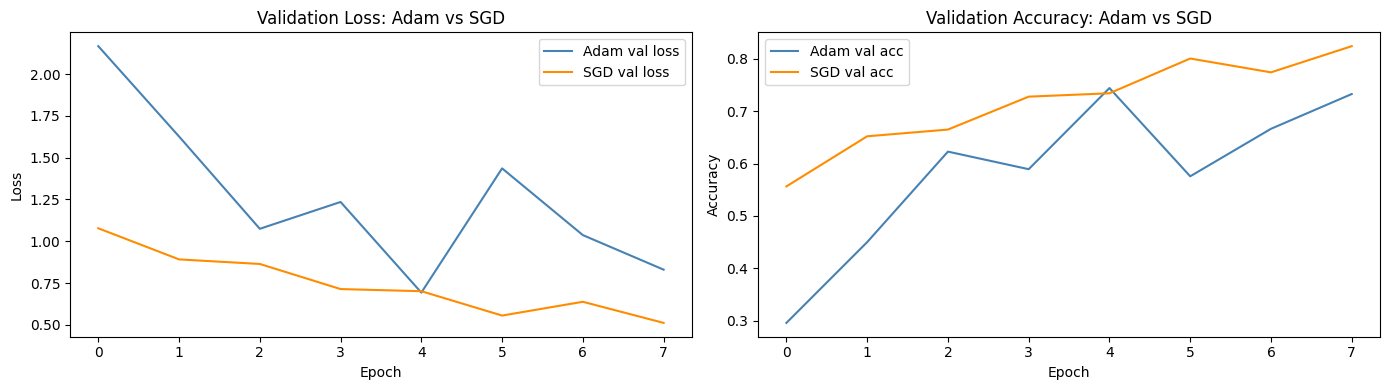


=== Optimizer Comparison Summary ===
Optimizer  Test accuracy  Test loss  Train time (min)
     Adam         0.7447     0.6962             11.86
      SGD         0.8303     0.4860             11.56


In [13]:
# ============================================================
# BLOCK 12: Optimizer Comparison (SGD vs Adam)
# ============================================================
# The assignment requires training the deeper model with SGD and
# Adam, then comparing convergence speed and final performance.
#
# Why this matters:
#   - Adam adapts the learning rate per parameter using estimates
#     of first and second moments of the gradients. It usually
#     converges faster and works well with default settings.
#   - SGD with momentum applies a constant learning rate but adds
#     a velocity term (momentum) so updates carry through plateaus.
#     SGD often generalizes slightly better but needs more careful
#     tuning and more epochs.
#
# To keep training time manageable, we train each version for 8
# epochs. The point is to compare how the optimizers behave,
# not to fully train.
# ============================================================

import time
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Number of epochs for each optimizer run
OPT_EPOCHS = 8


# ---------- Adam version ----------
print("Training deeper model with ADAM optimizer...\n")

# Build a fresh deeper model so previous training does not leak into this run
adam_model = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
adam_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()
adam_history = adam_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=OPT_EPOCHS,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,
                             restore_best_weights=True)],
    verbose=1
)
adam_time = time.time() - start_time
print(f"Adam training time: {adam_time/60:.2f} minutes")


# ---------- SGD version ----------
print("\nTraining deeper model with SGD optimizer...\n")

# Build another fresh model for the SGD run
sgd_model = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
# Momentum is included so SGD performs reasonably. Without it,
# vanilla SGD often gets stuck on plateaus.
sgd_model.compile(
    optimizer=SGD(learning_rate=1e-2, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()
sgd_history = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=OPT_EPOCHS,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,
                             restore_best_weights=True)],
    verbose=1
)
sgd_time = time.time() - start_time
print(f"SGD training time: {sgd_time/60:.2f} minutes")


# ---------- Test set evaluation for both ----------
print("\nEvaluating both optimizer runs on the test set...")
adam_test_loss, adam_test_acc = adam_model.evaluate(test_generator, verbose=0)
sgd_test_loss,  sgd_test_acc  = sgd_model.evaluate(test_generator, verbose=0)

print(f"Adam: test loss = {adam_test_loss:.4f}, test accuracy = {adam_test_acc:.4f}")
print(f"SGD : test loss = {sgd_test_loss:.4f}, test accuracy = {sgd_test_acc:.4f}")


# ---------- Comparison plots ----------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss comparison
axes[0].plot(adam_history.history["val_loss"], label="Adam val loss", color="steelblue")
axes[0].plot(sgd_history.history["val_loss"],  label="SGD val loss",  color="darkorange")
axes[0].set_title("Validation Loss: Adam vs SGD")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy comparison
axes[1].plot(adam_history.history["val_accuracy"], label="Adam val acc", color="steelblue")
axes[1].plot(sgd_history.history["val_accuracy"],  label="SGD val acc",  color="darkorange")
axes[1].set_title("Validation Accuracy: Adam vs SGD")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------- Summary table ----------
import pandas as pd

opt_compare = pd.DataFrame({
    "Optimizer": ["Adam", "SGD"],
    "Test accuracy": [round(adam_test_acc, 4), round(sgd_test_acc, 4)],
    "Test loss":     [round(adam_test_loss, 4), round(sgd_test_loss, 4)],
    "Train time (min)": [round(adam_time/60, 2), round(sgd_time/60, 2)]
})
print("\n=== Optimizer Comparison Summary ===")
print(opt_compare.to_string(index=False))

Building deeper model without dropout for ablation study...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training (no dropout)...

Epoch 1/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 101s 229ms/step - accuracy: 0.6635 - loss: 0.8933 - val_accuracy: 0.4836 - val_loss: 1.4663
Epoch 2/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 85s 216ms/step - accuracy: 0.7561 - loss: 0.6684 - val_accuracy: 0.6312 - val_loss: 1.0751
Epoch 3/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 85s 215ms/step - accuracy: 0.7908 - loss: 0.5701 - val_accuracy: 0.7575 - val_loss: 0.6801
Epoch 4/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 85s 215ms/step - accuracy: 0.8083 - loss: 0.5317 - val_accuracy: 0.7175 - val_loss: 0.7928
Epoch 5/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 93s 235ms/step - accuracy: 0.8168 - loss: 0.5092 - val_accuracy: 0.7175 - val_loss: 0.8222
Epoch 6/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 88s 222ms/step - accuracy: 0.8318 - loss: 0.4687 - val_accuracy: 0.7974 - val_loss: 0.5818
Epoch 7/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 86s 217ms/step - accuracy: 0.8429 - loss: 0.4338 - val_accuracy: 0.8081 - val_loss: 0.5080
Epoch 8/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 87s 220ms/step - accurac

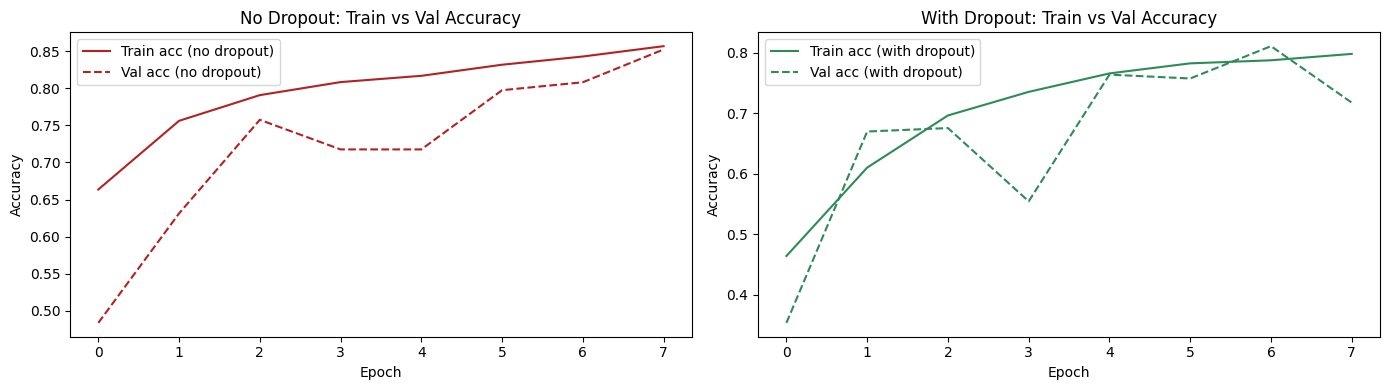


=== Ablation Study Summary ===
                   Variant  Test accuracy  Test loss  Train time (min)
With dropout (full deeper)          0.857     0.4168             20.48
     No dropout (ablation)          0.864     0.4068             11.83

Train-Val accuracy gap (no dropout) at epoch 8:   0.0044
Train-Val accuracy gap (with dropout) at epoch 8: 0.0807
A larger gap indicates more overfitting.


In [14]:
# ============================================================
# BLOCK 13: Ablation Study (Remove Dropout)
# ============================================================
# An ablation study removes one component from a model to see
# how much that component contributes. Here we remove Dropout
# from the deeper architecture and keep everything else the same.
#
# Expected behavior:
#   - Without dropout, training accuracy will rise faster and go
#     higher (model fits training data more aggressively).
#   - Validation accuracy will likely lag behind training accuracy,
#     showing a wider train/val gap. This is overfitting.
#   - Final test accuracy will be similar or slightly worse,
#     depending on how much overfitting actually occurred.
#
# Trained for 8 epochs to keep total runtime manageable. The
# comparison is made against the full deeper model trained earlier.
# ============================================================

import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def build_deeper_cnn_no_dropout(input_shape=(150, 150, 3), num_classes=6):
    """
    Same architecture as build_deeper_cnn but with all Dropout
    layers removed. BatchNormalization is kept so we can isolate
    the effect of dropout specifically.
    """
    model = Sequential(name="Deeper_CNN_NoDropout")

    # Conv block 1
    model.add(Conv2D(32, (3, 3), activation="relu",
                     input_shape=input_shape, padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # No Dropout here

    # Conv block 2
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Conv block 3
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Dense layers without dropout
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dense(64, activation="relu"))
    model.add(BatchNormalization())

    # Output
    model.add(Dense(num_classes, activation="softmax"))

    return model


# Build the no-dropout version
print("Building deeper model without dropout for ablation study...\n")
ablation_model = build_deeper_cnn_no_dropout(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
ablation_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train for 8 epochs (matches the optimizer comparison budget)
ABLATION_EPOCHS = 8
print("Training (no dropout)...\n")
start_time = time.time()
ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=ABLATION_EPOCHS,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,
                             restore_best_weights=True)],
    verbose=1
)
ablation_time = time.time() - start_time
print(f"\nNo-dropout training time: {ablation_time/60:.2f} minutes")


# Evaluate on test set
ablation_test_loss, ablation_test_acc = ablation_model.evaluate(test_generator, verbose=0)
print(f"\nAblation (no dropout) test loss:     {ablation_test_loss:.4f}")
print(f"Ablation (no dropout) test accuracy: {ablation_test_acc:.4f}")


# ---------- Comparison: with Dropout vs without Dropout ----------
# We compare the no-dropout run against the full deeper_model trained
# earlier. Note: that one trained for up to 20 epochs while this one
# only trained for 8, so for fairness we focus on the train/val gap
# rather than absolute final accuracy.

import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot the train vs val accuracy gap for each model
axes[0].plot(ablation_history.history["accuracy"],
             label="Train acc (no dropout)", color="firebrick")
axes[0].plot(ablation_history.history["val_accuracy"],
             label="Val acc (no dropout)", color="firebrick", linestyle="--")
axes[0].set_title("No Dropout: Train vs Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Use the first 8 epochs of the original deeper model history for
# a fair visual comparison (both models then run for the same epochs).
n = min(ABLATION_EPOCHS, len(deeper_history.history["accuracy"]))
axes[1].plot(deeper_history.history["accuracy"][:n],
             label="Train acc (with dropout)", color="seagreen")
axes[1].plot(deeper_history.history["val_accuracy"][:n],
             label="Val acc (with dropout)", color="seagreen", linestyle="--")
axes[1].set_title("With Dropout: Train vs Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


# Summary table
ablation_compare = pd.DataFrame({
    "Variant": ["With dropout (full deeper)", "No dropout (ablation)"],
    "Test accuracy": [round(deeper_metrics["accuracy"], 4),
                      round(ablation_test_acc, 4)],
    "Test loss":     [round(deeper_test_loss, 4),
                      round(ablation_test_loss, 4)],
    "Train time (min)": [round(deeper_metrics["train_time_min"], 2),
                         round(ablation_time/60, 2)]
})
print("\n=== Ablation Study Summary ===")
print(ablation_compare.to_string(index=False))


# Compute and print the train-vs-val gap at the last epoch for both
# (a key indicator of overfitting)
gap_no_dropout = (ablation_history.history["accuracy"][-1]
                  - ablation_history.history["val_accuracy"][-1])
gap_with_dropout = (deeper_history.history["accuracy"][n-1]
                    - deeper_history.history["val_accuracy"][n-1])
print(f"\nTrain-Val accuracy gap (no dropout) at epoch {ABLATION_EPOCHS}:   {gap_no_dropout:.4f}")
print(f"Train-Val accuracy gap (with dropout) at epoch {n}: {gap_with_dropout:.4f}")
print("A larger gap indicates more overfitting.")

In [15]:
# ============================================================
# BLOCK 14: Transfer Learning - Feature Extraction
# ============================================================
# Why transfer learning:
#   Pre-trained models like MobileNetV2 have already learned rich
#   visual features from millions of ImageNet images (edges,
#   textures, object parts). For our 6-class scene classification,
#   we can reuse those features instead of learning them from
#   scratch. This usually gives much better accuracy with less
#   training time and less data.
#
# Why MobileNetV2:
#   - Small (about 14 MB of weights) so training is fast on Colab
#   - Designed for efficient inference, expects 224x224 inputs by
#     default but accepts other sizes
#   - Matches our compute budget on a free T4 GPU
#
# Strategy in this block (feature extraction):
#   1. Load MobileNetV2 with ImageNet weights, no top classifier
#   2. Freeze the base so its weights do not change during training
#   3. Add a new classifier head suited to 6 classes
#   4. Train only the new head for a few epochs
#
# Input size:
#   We use 224x224 here because the pre-trained model expects
#   that size for best results. We resize on the fly with new
#   data generators.
# ============================================================

import time
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------- Step 1: New data generators with 224x224 input ----------
# MobileNetV2 has its own preprocessing function (preprocess_input)
# that scales pixel values to the range [-1, 1] which matches how
# the model was originally trained. We pass it via preprocessing_function.

TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)
tl_val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
tl_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_generator = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)
tl_val_generator = tl_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
tl_test_generator = tl_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


# ---------- Step 2: Load MobileNetV2 base ----------
# include_top=False removes the original 1000-class ImageNet classifier.
# We will add our own classifier on top.

base_model = MobileNetV2(
    input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model so its weights are not updated during this stage.
# Only the new classifier head will train. This is "feature extraction".
base_model.trainable = False
print(f"MobileNetV2 base loaded. Total layers: {len(base_model.layers)}")
print(f"Trainable: {base_model.trainable}")


# ---------- Step 3: Build the new classifier head ----------
# GlobalAveragePooling2D collapses each feature map into a single
# value, producing a fixed-size vector regardless of input image
# size. This is preferred over Flatten for transfer learning
# because it has fewer parameters and reduces overfitting risk.

inputs = Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))
# training=False ensures the BatchNorm layers in the base run in
# inference mode even when the rest of the model is training.
# This is a known requirement when fine-tuning models with BN.
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)                          # mild regularization
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

transfer_model = Model(inputs, outputs, name="MobileNetV2_TransferLearning")

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
transfer_model.summary()


# ---------- Step 4: Train the head only (feature extraction) ----------
print("\nStage 1: Feature extraction (base frozen)...\n")
start_time = time.time()

fe_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=8,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6)
    ],
    verbose=1
)

fe_time = time.time() - start_time
print(f"\nFeature extraction stage completed in {fe_time/60:.2f} minutes.")

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded. Total layers: 154
Trainable: False


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Stage 1: Feature extraction (base frozen)...

Epoch 1/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 194s 442ms/step - accuracy: 0.8370 - loss: 0.4429 - val_accuracy: 0.9087 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 2/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 148s 374ms/step - accuracy: 0.8782 - loss: 0.3315 - val_accuracy: 0.9108 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 3/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 143s 362ms/step - accuracy: 0.8820 - loss: 0.3113 - val_accuracy: 0.9265 - val_loss: 0.2427 - learning_rate: 0.0010
Epoch 4/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 143s 362ms/step - accuracy: 0.8897 - loss: 0.2968 - val_accuracy: 0.9108 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 5/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 143s 361ms/step - accuracy: 0.8873 - loss: 0.2961 - val_accuracy: 0.9101 - val_loss: 0.2557 - learning_rate: 0.0010
Epoch 6/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 147s 372ms/step - accuracy: 0.9013 - loss: 0.2718 - val_accuracy: 0.9215 - val_loss: 0.2307 - learning_rate: 5.0000e-04
Epoch 7/8
395/395 ━

In [16]:
# ============================================================
# BLOCK 15: Transfer Learning - Fine-Tuning
# ============================================================
# After feature extraction, the new classifier head is trained.
# Now we unfreeze the top portion of the pre-trained base and
# continue training at a much lower learning rate. This lets
# the higher layers adapt slightly to our scene-classification
# task while keeping the lower-layer features intact.
#
# Key practices:
#   - Unfreeze only the top portion of the base. Lower layers
#     learn generic features (edges, textures) and should stay
#     frozen. Top layers learn task-specific features.
#   - Use a much lower learning rate (1e-5). A high LR would
#     destroy the carefully learned ImageNet weights
#     (catastrophic forgetting).
#   - Recompile with the new learning rate. Without recompiling,
#     the trainable changes will not take effect properly.
# ============================================================

# Unfreeze the base model
base_model.trainable = True

# But only fine-tune the top layers. MobileNetV2 has 154 layers;
# we keep the first ~100 frozen and let the last ~54 train.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Count trainable layers for confirmation
trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Total base layers: {len(base_model.layers)}")
print(f"Frozen up to layer index: {fine_tune_at}")
print(f"Trainable base layers now: {trainable_count}")


# Recompile with a much lower learning rate to avoid wrecking
# the pre-trained weights.
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStage 2: Fine-tuning (top layers unfrozen)...\n")
start_time = time.time()

ft_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=6,                          # fewer epochs because LR is tiny
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-7)
    ],
    verbose=1
)

ft_time = time.time() - start_time
print(f"\nFine-tuning stage completed in {ft_time/60:.2f} minutes.")
total_tl_time = fe_time + ft_time
print(f"Total transfer learning time: {total_tl_time/60:.2f} minutes.")


# Save the fine-tuned model and history
save_model(transfer_model, "transfer_finetuned")
save_history(ft_history, "transfer_finetuned")

Total base layers: 154
Frozen up to layer index: 100
Trainable base layers now: 54

Stage 2: Fine-tuning (top layers unfrozen)...

Epoch 1/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 189s 420ms/step - accuracy: 0.8143 - loss: 0.4977 - val_accuracy: 0.9173 - val_loss: 0.2732 - learning_rate: 1.0000e-05
Epoch 2/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 148s 376ms/step - accuracy: 0.8724 - loss: 0.3515 - val_accuracy: 0.9165 - val_loss: 0.2560 - learning_rate: 1.0000e-05
Epoch 3/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 150s 379ms/step - accuracy: 0.8896 - loss: 0.3083 - val_accuracy: 0.9101 - val_loss: 0.2514 - learning_rate: 1.0000e-05
Epoch 4/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 151s 382ms/step - accuracy: 0.8952 - loss: 0.2899 - val_accuracy: 0.9208 - val_loss: 0.2274 - learning_rate: 1.0000e-05
Epoch 5/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 149s 378ms/step - accuracy: 0.9003 - loss: 0.2746 - val_accuracy: 0.9165 - val_loss: 0.2216 - learning_rate: 1.0000e-05
Epoch 6/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 147s 373ms/step - accuracy: 0.9086 

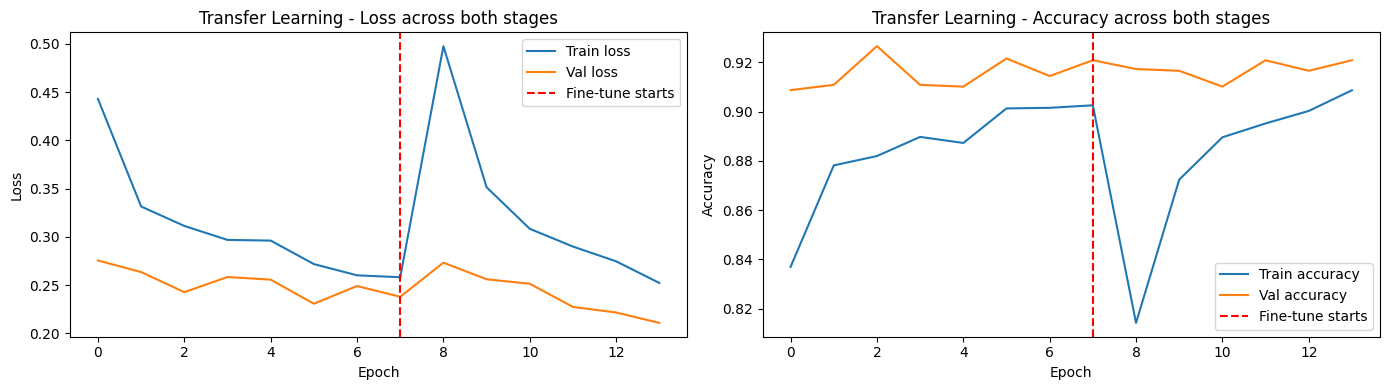


Evaluating transfer learning model on the test set...
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9207 - loss: 0.2069

Transfer learning test loss:     0.2069
Transfer learning test accuracy: 0.9207
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step

Classification report (Transfer Learning):

              precision    recall  f1-score   support

   buildings       0.94      0.94      0.94       437
      forest       0.99      1.00      0.99       474
     glacier       0.93      0.78      0.85       553
    mountain       0.80      0.92      0.86       525
         sea       0.95      0.97      0.96       510
      street       0.94      0.94      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000


Summary metrics (Transfer Learning): {'accuracy': 0.9206666666666666, 'precision': 0.9255235533916056, 'recall': 0.9240867105174203, 'f1': 0.9229787314601022, '

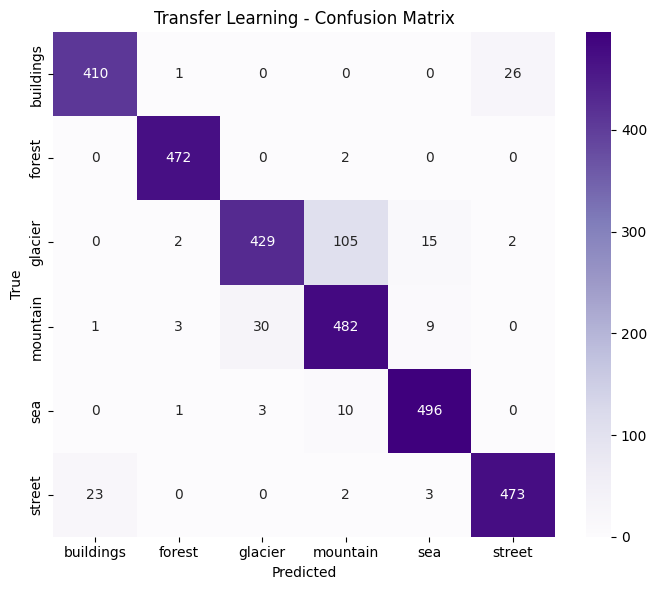

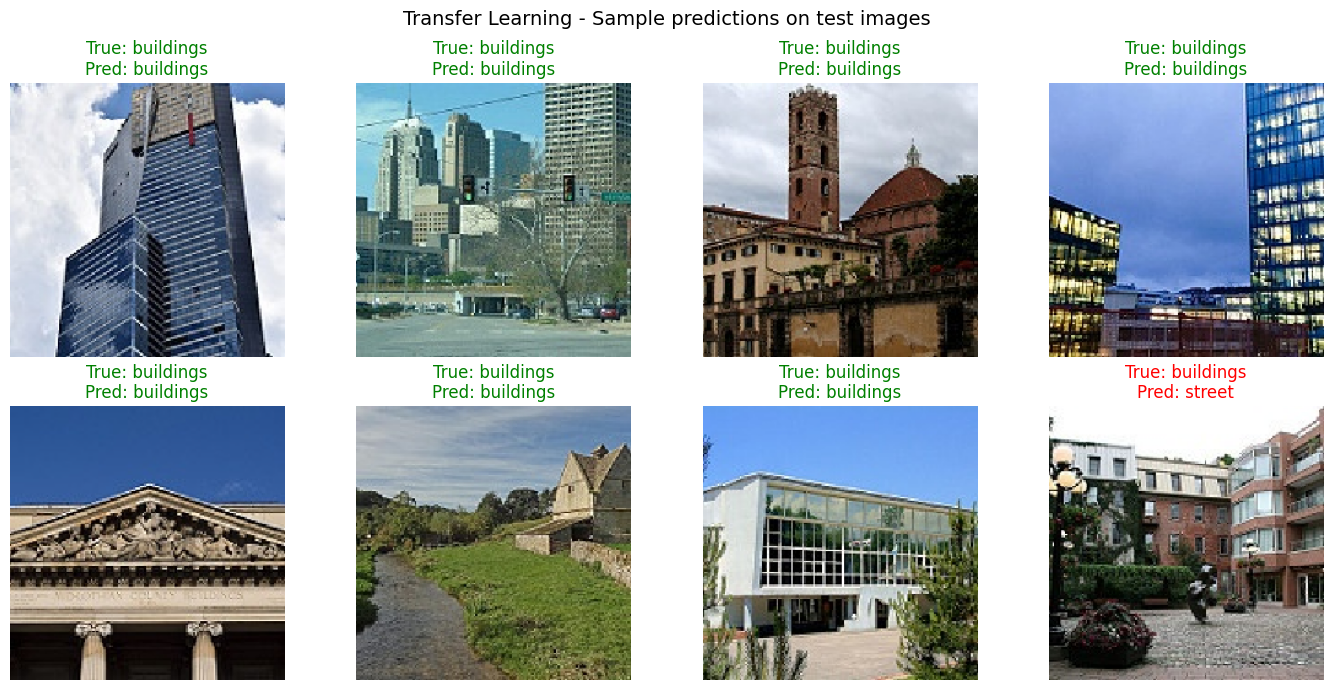


=== Final Comparison: Baseline vs Deeper vs Transfer Learning ===
                   accuracy  precision  recall      f1  train_time_min
Baseline CNN         0.8787     0.8801  0.8813  0.8798         19.4618
Deeper CNN           0.8570     0.8590  0.8591  0.8578         20.4792
Transfer Learning    0.9207     0.9255  0.9241  0.9230         35.6796


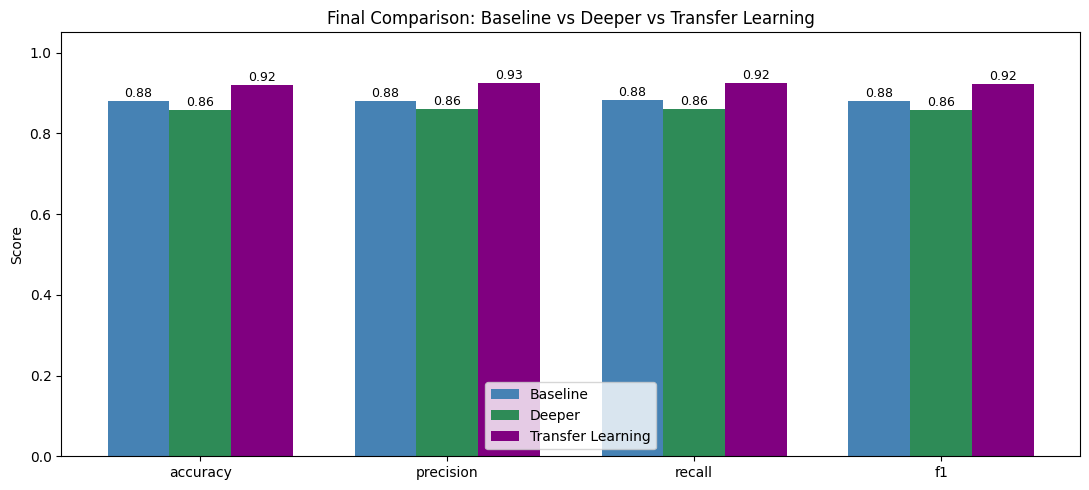

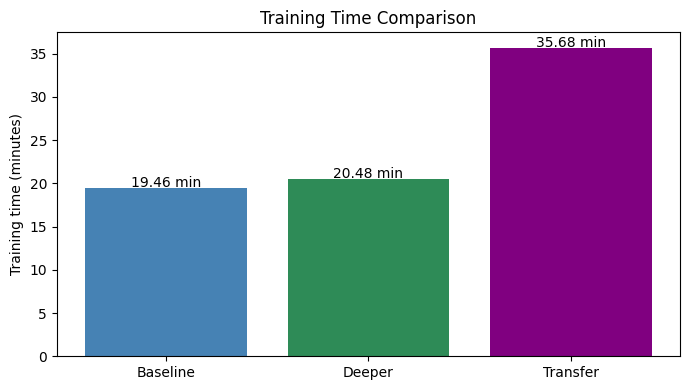

In [17]:
# ============================================================
# BLOCK 16: Evaluate Transfer Learning and Final Comparison
# ============================================================
# This block does three things:
#   1. Plot training curves for both stages of transfer learning
#      (feature extraction stage 1, then fine-tuning stage 2).
#   2. Evaluate the final fine-tuned model on the test set, with
#      a classification report, confusion matrix, and sample
#      predictions.
#   3. Put all three Vision models side by side: Baseline CNN,
#      Deeper CNN, and Transfer Learning (MobileNetV2). This is
#      the comparison the assignment explicitly asks for in
#      Part B's "Discuss whether transfer learning outperforms
#      training from scratch".
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)


# ---------- Step 1: Plot transfer learning curves ----------
# We plot both stages on a single figure. A vertical dashed line
# marks the transition from feature extraction to fine-tuning.

fe_epochs = len(fe_history.history["loss"])
ft_epochs = len(ft_history.history["loss"])

# Concatenate the two stages so we can see the full training journey
combined_loss     = fe_history.history["loss"] + ft_history.history["loss"]
combined_val_loss = fe_history.history["val_loss"] + ft_history.history["val_loss"]
combined_acc      = fe_history.history["accuracy"] + ft_history.history["accuracy"]
combined_val_acc  = fe_history.history["val_accuracy"] + ft_history.history["val_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(combined_loss,     label="Train loss")
axes[0].plot(combined_val_loss, label="Val loss")
# Vertical line shows where stage 2 began
axes[0].axvline(x=fe_epochs - 1, color="red", linestyle="--",
                label="Fine-tune starts")
axes[0].set_title("Transfer Learning - Loss across both stages")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(combined_acc,     label="Train accuracy")
axes[1].plot(combined_val_acc, label="Val accuracy")
axes[1].axvline(x=fe_epochs - 1, color="red", linestyle="--",
                label="Fine-tune starts")
axes[1].set_title("Transfer Learning - Accuracy across both stages")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------- Step 2: Evaluate on test set ----------
print("\nEvaluating transfer learning model on the test set...")
tl_test_loss, tl_test_acc = transfer_model.evaluate(tl_test_generator, verbose=1)
print(f"\nTransfer learning test loss:     {tl_test_loss:.4f}")
print(f"Transfer learning test accuracy: {tl_test_acc:.4f}")


# ---------- Step 3: Predictions and classification report ----------
tl_test_generator.reset()
y_pred_probs_tl = transfer_model.predict(tl_test_generator, verbose=1)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)
y_true_tl = tl_test_generator.classes

print("\nClassification report (Transfer Learning):\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

transfer_metrics = {
    "accuracy":  accuracy_score(y_true_tl, y_pred_tl),
    "precision": precision_score(y_true_tl, y_pred_tl, average="macro"),
    "recall":    recall_score(y_true_tl, y_pred_tl, average="macro"),
    "f1":        f1_score(y_true_tl, y_pred_tl, average="macro"),
    "train_time_min": (fe_time + ft_time) / 60
}
print("\nSummary metrics (Transfer Learning):", transfer_metrics)


# ---------- Step 4: Confusion matrix ----------
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Transfer Learning - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ---------- Step 5: Sample predictions ----------
tl_test_generator.reset()
sample_imgs, sample_labels = next(tl_test_generator)
sample_preds = transfer_model.predict(sample_imgs, verbose=0)

# Note: these images were preprocessed for MobileNetV2 (range -1 to 1)
# so we rescale them back to 0-1 just for display purposes.
display_imgs = (sample_imgs + 1.0) / 2.0
display_imgs = np.clip(display_imgs, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(display_imgs[i])
    true_idx = sample_labels[i].argmax()
    pred_idx = sample_preds[i].argmax()
    color = "green" if true_idx == pred_idx else "red"
    ax.set_title(
        f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}",
        color=color
    )
    ax.axis("off")

plt.suptitle("Transfer Learning - Sample predictions on test images",
             fontsize=14)
plt.tight_layout()
plt.show()


# ---------- Step 6: Three-way comparison (Baseline / Deeper / TL) ----------
# This table and chart go straight into the report and answer the
# assignment's headline question for Part B.

final_compare = pd.DataFrame(
    [baseline_metrics, deeper_metrics, transfer_metrics],
    index=["Baseline CNN", "Deeper CNN", "Transfer Learning"]
).round(4)
print("\n=== Final Comparison: Baseline vs Deeper vs Transfer Learning ===")
print(final_compare)


# Bar chart of metrics
metric_cols = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metric_cols))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, final_compare.loc["Baseline CNN", metric_cols],
        width, label="Baseline", color="steelblue")
plt.bar(x,         final_compare.loc["Deeper CNN", metric_cols],
        width, label="Deeper", color="seagreen")
plt.bar(x + width, final_compare.loc["Transfer Learning", metric_cols],
        width, label="Transfer Learning", color="purple")
plt.xticks(x, metric_cols)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Final Comparison: Baseline vs Deeper vs Transfer Learning")
plt.legend()

# Print the value above each bar so it is easy to read
for i, m in enumerate(metric_cols):
    plt.text(i - width, final_compare.loc["Baseline CNN", m] + 0.01,
             f"{final_compare.loc['Baseline CNN', m]:.2f}",
             ha="center", fontsize=9)
    plt.text(i,         final_compare.loc["Deeper CNN", m] + 0.01,
             f"{final_compare.loc['Deeper CNN', m]:.2f}",
             ha="center", fontsize=9)
    plt.text(i + width, final_compare.loc["Transfer Learning", m] + 0.01,
             f"{final_compare.loc['Transfer Learning', m]:.2f}",
             ha="center", fontsize=9)

plt.tight_layout()
plt.show()


# Bar chart of training time
plt.figure(figsize=(7, 4))
plt.bar(["Baseline", "Deeper", "Transfer"],
        [baseline_metrics["train_time_min"],
         deeper_metrics["train_time_min"],
         transfer_metrics["train_time_min"]],
        color=["steelblue", "seagreen", "purple"])
plt.ylabel("Training time (minutes)")
plt.title("Training Time Comparison")
for i, v in enumerate([baseline_metrics["train_time_min"],
                       deeper_metrics["train_time_min"],
                       transfer_metrics["train_time_min"]]):
    plt.text(i, v + 0.1, f"{v:.2f} min", ha="center")
plt.tight_layout()
plt.show()

In [18]:
# Save the baseline model and history so we don't lose them tomorrow
import pickle, os
os.makedirs("/content/saved", exist_ok=True)

baseline_model.save("/content/saved/baseline_model.keras")
with open("/content/saved/baseline_history.pkl", "wb") as f:
    pickle.dump(baseline_history.history, f)
print("Baseline saved.")

Baseline saved.
